In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib -q

In [ ]:
!pip install pdfplumber easyocr pdf2image Pillow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 10.7 MB/s eta 0:00:00


In [ ]:
import os, re, csv, warnings
import numpy as np
import pandas as pd
import pdfplumber
import easyocr
from PIL import Image
from pdf2image import convert_from_path
warnings.filterwarnings('ignore')

from google.colab import files
import io

print('='*60)
print('  KONVERTER REKENING KORAN → CSV')
print('='*60)

print('📂 Silakan upload file rekening koran (PDF/JPG/PNG):')
uploaded = files.upload()

if not uploaded:
    raise ValueError('❌ Tidak ada file yang diupload!')

filename  = list(uploaded.keys())[0]
file_data = uploaded[filename]

INPUT_FILE = filename
with open(INPUT_FILE, 'wb') as f:
    f.write(file_data)

OUTPUT_CSV = os.path.splitext(filename)[0] + '_output.csv'

print(f'✅ File diterima : {filename}')
print(f'💾 Output CSV   : {OUTPUT_CSV}')

OCR_LANG = ['id', 'en']
USE_GPU  = False

SUPPORTED_IMG = {'.jpg', '.jpeg', '.png', '.tiff', '.tif', '.bmp', '.webp'}
DEFAULT_COLS  = ['Tanggal', 'Keterangan', 'Debet', 'Kredit', 'Saldo']
RE_NUMBER     = re.compile(r'[\d.,]+')
RE_DATE       = re.compile(
    r'^(\d{1,2}[/\-.])\d{1,2}[/\-.]\d{2,4}'
    r'|^\d{4}[/\-.]\d{1,2}[/\-.]\d{1,2}'
    r'|^\d{1,2}\s+\w{3,9}\s+\d{4}'
)

def clean_number(text):
    if not text: return ''
    text = text.strip().replace(' ', '')
    if re.match(r'^\d{1,3}(\.\d{3})*(,\d+)?$', text):
        text = text.replace('.', '').replace(',', '.')
    elif re.match(r'^\d{1,3}(,\d{3})*(\.\d+)?$', text):
        text = text.replace(',', '')
    try:    return str(float(text))
    except: return text

def looks_like_transaction(row):
    text     = ' '.join(str(c) for c in row if c)
    has_date = bool(re.search(r'\d{1,2}[/\-.\s]\d{1,2}[/\-.\s]\d{2,4}', text))
    has_num  = len(RE_NUMBER.findall(text)) >= 2
    return has_date or has_num

def normalize_row(row, n):
    row = [str(c).strip() if c else '' for c in row]
    if len(row) < n: row += [''] * (n - len(row))
    return row[:n]

def extract_pdfplumber(path):
    all_rows, header = [], None
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            tables = page.extract_tables()
            if not tables:
                raw = page.extract_text() or ''
                for line in raw.splitlines():
                    parts = re.split(r'\s{2,}|\t', line.strip())
                    if parts and looks_like_transaction(parts):
                        all_rows.append(parts)
                continue
            for table in tables:
                if not table: continue
                if header is None and table[0]:
                    first = [str(c).strip().lower() for c in table[0] if c]
                    if any(k in ' '.join(first) for k in
                           ['tanggal','date','ket','debet','kredit','saldo','balance']):
                        header = [str(c).strip() for c in table[0]]
                        table  = table[1:]
                for row in table:
                    if row and looks_like_transaction(row):
                        all_rows.append(row)
    if not all_rows: return pd.DataFrame()
    cols = header if header else DEFAULT_COLS
    n    = len(cols)
    return pd.DataFrame([normalize_row(r, n) for r in all_rows], columns=cols[:n])

def ocr_image(image, reader):
    results = reader.readtext(np.array(image), detail=1, paragraph=False)
    buckets = {}
    for bbox, text, conf in results:
        if conf < 0.3: continue
        y = int((bbox[0][1] + bbox[2][1]) / 2)
        key = next((k for k in buckets if abs(k - y) <= 12), y)
        buckets.setdefault(key, []).append((bbox[0][0], text))
    return ['  '.join(t for _, t in sorted(v)) for _, v in sorted(buckets.items())]

def parse_ocr_lines(lines):
    RE_MONEY = re.compile(r'\b\d[\d.,]+\b')
    rows = []
    for line in lines:
        line = line.strip()
        if not line: continue
        dm   = RE_DATE.match(line)
        nums = RE_MONEY.findall(line)
        if dm or len(nums) >= 2:
            tanggal = dm.group(0) if dm else ''
            desc    = line[len(tanggal):].strip() if tanggal else line
            ns      = nums[-3:] if len(nums) >= 3 else nums
            while len(ns) < 3: ns = [''] + ns
            debet, kredit, saldo = ns
            for n in ns:
                desc = desc.replace(n, '').strip(' ,;')
            rows.append({'Tanggal': tanggal, 'Keterangan': desc,
                         'Debet': clean_number(debet),
                         'Kredit': clean_number(kredit),
                         'Saldo': clean_number(saldo)})
    return pd.DataFrame(rows, columns=DEFAULT_COLS) if rows else pd.DataFrame()

def extract_easyocr(path, reader):
    ext = os.path.splitext(path)[1].lower()
    images = convert_from_path(path, dpi=300) if ext == '.pdf' \
             else [Image.open(path).convert('RGB')]
    lines = []
    for i, img in enumerate(images, 1):
        print(f'  ↳ OCR halaman {i}/{len(images)}...')
        lines.extend(ocr_image(img, reader))
    return parse_ocr_lines(lines)

def detect_pdf_type(path):
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages[:3]:
            if len((page.extract_text() or '').strip()) > 50:
                return 'digital'
    return 'scan'

def convert_to_csv(input_path, output_path):
    if not os.path.exists(input_path):
        print(f'❌ File tidak ditemukan: {input_path}')
        return None

    ext = os.path.splitext(input_path)[1].lower()
    df  = pd.DataFrame()

    if ext == '.pdf':
        pdf_type = detect_pdf_type(input_path)
        print(f'📄 PDF terdeteksi: {pdf_type.upper()}')
        if pdf_type == 'digital':
            print('🔍 Menggunakan pdfplumber...')
            df = extract_pdfplumber(input_path)
        if df.empty:
            print('🔍 Menggunakan easyocr (OCR)...')
            reader = easyocr.Reader(OCR_LANG, gpu=USE_GPU, verbose=False)
            df = extract_easyocr(input_path, reader)
    elif ext in SUPPORTED_IMG:
        print('🖼️  File gambar terdeteksi, menggunakan easyocr...')
        reader = easyocr.Reader(OCR_LANG, gpu=USE_GPU, verbose=False)
        df = extract_easyocr(input_path, reader)
    else:
        print(f'❌ Format tidak didukung: {ext}')
        return None

    if df.empty:
        print('⚠️  Tidak ada transaksi yang berhasil diekstrak.')
        return None

    df.to_csv(output_path, index=False, encoding='utf-8-sig',
              quoting=csv.QUOTE_NONNUMERIC)
    print(f'\n✅ Berhasil mengekstrak {len(df)} baris transaksi')
    print(f'✅ Tersimpan ke: {output_path}')
    print('\n📋 Preview 5 baris pertama:')
    display(df.head())
    return df

df_rekening = convert_to_csv(INPUT_FILE, OUTPUT_CSV)


  KONVERTER REKENING KORAN → CSV
📂 Silakan upload file rekening koran (PDF/JPG/PNG):


Saving data_koran.pdf to data_koran.pdf
✅ File diterima : data_koran.pdf
💾 Output CSV   : data_koran_output.csv
📄 PDF terdeteksi: DIGITAL
🔍 Menggunakan pdfplumber...

✅ Berhasil mengekstrak 19963 baris transaksi
✅ Tersimpan ke: data_koran_output.csv

📋 Preview 5 baris pertama:


,Amount,Use Chip,Merchant City,Merchant State,MCC,Is Fraud?,Amount_Rupiah,date
0,134.09,Swipe Transactio,nLa Verne,CA,5300,No,2212485.0,2002-09-01
1,38.48,Swipe Transactio,nMonterey Park,CA,5411,No,634920.0,2002-09-01
2,120.34,Swipe Transactio,nMonterey Park,CA,5411,No,1985610.0,2002-09-02
3,128.95,Swipe Transactio,nMonterey Park,CA,5651,No,2127675.0,2002-09-02
4,104.71,Swipe Transactio,nLa Verne,CA,5912,No,1727715.0,2002-09-03


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow versi: {tf.__version__}')

✅ TensorFlow versi: 2.20.0


In [ ]:
import re
import numpy as np

df_raw = df_rekening.copy()

# Rename the problematic column from 'Amount_Rupiah date' to 'combined_data'
# This is done to make parsing explicit
if 'Amount_Rupiah date' in df_raw.columns:
    df_raw.rename(columns={'Amount_Rupiah date': 'combined_data'}, inplace=True)

# Regex to find common date patterns anywhere in the string
RE_DATE_GLOBAL = r'(\d{1,2}[/\-. ]\d{1,2}[/\-. ]\d{2,4}|\d{4}[/\-. ]\d{1,2}[/\-. ]\d{1,2}|\d{1,2}\s+\w{3,9}\s+\d{4})'

# Function to extract the last date found in a string
def extract_last_date(text):
    if not isinstance(text, str): return None
    matches = re.findall(RE_DATE_GLOBAL, text)
    if matches:
        # re.findall with multiple capturing groups returns a list of tuples.
        # We need to extract the actual date string from the last non-empty match.
        for match_tuple in reversed(matches):
            for part in reversed(match_tuple):
                if part:
                    return part
    return None

# Function to extract numerical values that could be Amount_Rupiah
def extract_amount_rupiah(text):
    if not isinstance(text, str): return np.nan
    # Find numbers that look like money, trying to avoid dates
    numbers = re.findall(r'\b[\d,.]+\b', text) # Finds sequences of digits, commas, dots
    if numbers:
        # Prioritize numbers not immediately preceded/followed by date separators or part of known date formats
        for num_str in reversed(numbers):
            try:
                # Clean and convert to float (e.g., '1.000.000,00' -> '1000000.00')
                # This is a heuristic, assuming common Indonesian/European number formats
                cleaned_num = num_str.replace('.', '').replace(',', '.')
                return float(cleaned_num)
            except ValueError:
                continue
    return np.nan

# Apply extraction logic
if 'combined_data' in df_raw.columns:
    df_raw['date'] = df_raw['combined_data'].apply(extract_last_date)
    df_raw['Amount_Rupiah'] = df_raw['combined_data'].apply(extract_amount_rupiah)
else:
    # Fallback if 'combined_data' isn't found (e.g., if the user manually fixed upstream)
    # In this case, assume 'date' and 'Amount_Rupiah' might already exist or are missing.
    if 'date' not in df_raw.columns:
        df_raw['date'] = pd.Series(dtype='datetime64[ns]') # Create empty date column
    if 'Amount_Rupiah' not in df_raw.columns:
        df_raw['Amount_Rupiah'] = np.nan # Create empty Amount_Rupiah column

# Ensure 'Amount' column exists, often derived from 'Amount_Rupiah'
if 'Amount' not in df_raw.columns:
    df_raw['Amount'] = df_raw['Amount_Rupiah'] # Assuming Amount_Rupiah can serve as Amount

# Convert extracted 'date' to datetime objects, coercing errors to NaT
df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')

# Extract Year, Month, Day from the 'date' column
df_raw['Year']  = df_raw['date'].dt.year
df_raw['Month'] = df_raw['date'].dt.month
df_raw['Day']   = df_raw['date'].dt.day

print(f'✅ Data berhasil diload: {len(df_raw):,} transaksi')
df_raw.head()

✅ Data berhasil diload: 19,963 transaksi


,Amount,Use Chip,Merchant City,Merchant State,MCC,Is Fraud?,Amount_Rupiah,date,Year,Month,Day
0,134.09,Swipe Transactio,nLa Verne,CA,5300,No,2212485.0,2002-09-01,2002,9,1
1,38.48,Swipe Transactio,nMonterey Park,CA,5411,No,634920.0,2002-09-01,2002,9,1
2,120.34,Swipe Transactio,nMonterey Park,CA,5411,No,1985610.0,2002-09-02,2002,9,2
3,128.95,Swipe Transactio,nMonterey Park,CA,5651,No,2127675.0,2002-09-02,2002,9,2
4,104.71,Swipe Transactio,nLa Verne,CA,5912,No,1727715.0,2002-09-03,2002,9,3


In [ ]:
#Validasi
print('=== CEK KELENGKAPAN DATA ===\n')
print(f'Missing values per kolom:')
print(df_raw.isnull().sum())
print(f'\nTotal missing values: {df_raw.isnull().sum().sum()}')
print(f'\nRentang tahun: {df_raw["Year"].min()} - {df_raw["Year"].max()}')
print(f'Total bulan unik: {df_raw.groupby(["Year","Month"]).ngroups}')
print(f'\nStatistik Amount:')
print(df_raw['Amount'].describe())

=== CEK KELENGKAPAN DATA ===

Missing values per kolom:
Amount            0
Use Chip          0
Merchant City     0
Merchant State    0
MCC               0
Is Fraud?         0
Amount_Rupiah     0
date              0
Year              0
Month             0
Day               0
dtype: int64

Total missing values: 0

Rentang tahun: 2002 - 2020
Total bulan unik: 210

Statistik Amount:
count     19963
unique    11400
top       140.0
freq         81
Name: Amount, dtype: object


✅ Feature engineering selesai
   Total bulan : 198
   Periode     : 2003-09-01 → 2020-02-01


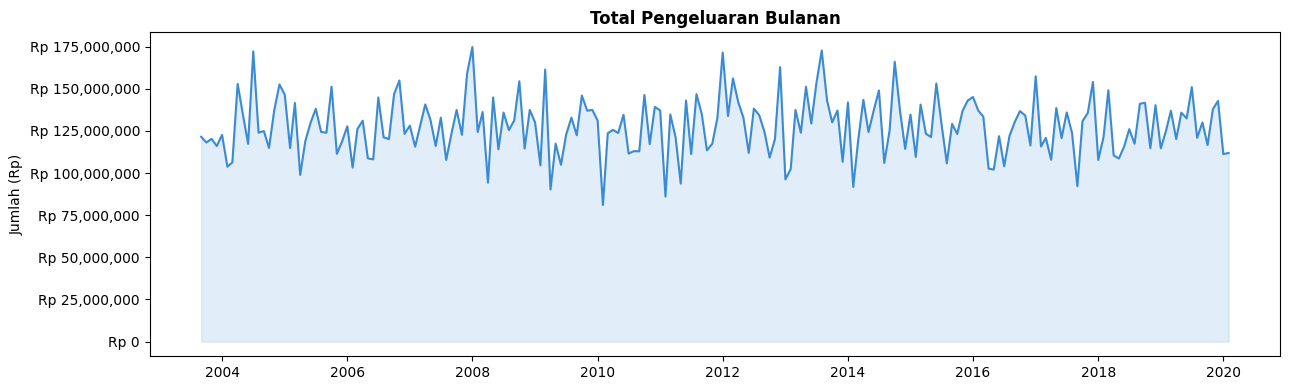

In [ ]:
# Agregasi ke total pengeluaran per bulan
df = df_raw.copy()
df['Amount_Rupiah'] = pd.to_numeric(df['Amount_Rupiah'], errors='coerce')

monthly = df.groupby(['Year', 'Month']).agg(
    total_amount = ('Amount_Rupiah', 'sum'),
    jumlah_trx   = ('Amount_Rupiah', 'count'),
    rata_rata    = ('Amount_Rupiah', 'mean'),
    std_amount   = ('Amount_Rupiah', 'std')
).reset_index()

monthly['ds'] = pd.to_datetime(dict(
    year=monthly['Year'], month=monthly['Month'], day=1))
monthly = monthly.sort_values('ds').reset_index(drop=True)
monthly['std_amount'] = monthly['std_amount'].fillna(0)

# Fitur tambahan
monthly['month_sin'] = np.sin(2 * np.pi * monthly['Month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['Month'] / 12)
monthly['lag_1']     = monthly['total_amount'].shift(1)
monthly['lag_3']     = monthly['total_amount'].shift(3)
monthly['lag_12']    = monthly['total_amount'].shift(12)
monthly['rolling_3'] = monthly['total_amount'].shift(1).rolling(3).mean()
monthly['rolling_6'] = monthly['total_amount'].shift(1).rolling(6).mean()

monthly = monthly.dropna().reset_index(drop=True)

print(f'✅ Feature engineering selesai')
print(f'   Total bulan : {len(monthly)}')
print(f'   Periode     : {monthly["ds"].min().date()} → {monthly["ds"].max().date()}')

# Visualisasi tren
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['ds'], monthly['total_amount'], color='#3B8BD4', linewidth=1.5)
ax.fill_between(monthly['ds'], monthly['total_amount'], alpha=0.15, color='#3B8BD4')
ax.set_title('Total Pengeluaran Bulanan', fontweight='bold')
ax.set_ylabel('Jumlah (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('tren_pengeluaran.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Normalisasi &  sequences
LOOKBACK    = 12
TRAIN_RATIO = 0.85
TARGET_COL  = 0

feature_cols = [
    'total_amount', 'jumlah_trx', 'rata_rata', 'std_amount',
    'month_sin', 'month_cos', 'rolling_3', 'rolling_6'
]

data = monthly[feature_cols].values
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])
        y.append(data[i, TARGET_COL])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, LOOKBACK)
split = int(len(X) * TRAIN_RATIO)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
n_features = X_train.shape[2]

print(f'✅ Dataset siap untuk training')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')

✅ Dataset siap untuk training
   X_train : (158, 12, 8)
   X_test  : (28, 12, 8)


In [ ]:
class TemporalAttentionLayer(layers.Layer):

    def __init__(self, units=32, **kwargs):
        super(TemporalAttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units, activation='tanh')
        self.V = layers.Dense(1, use_bias=False)

    def call(self, inputs):
        score           = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        context         = tf.reduce_sum(attention_weights * inputs, axis=1)
        return context, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

print('✅ Custom Layer: TemporalAttentionLayer')

✅ Custom Layer: TemporalAttentionLayer


In [ ]:
class SmartFinanceLoss(keras.losses.Loss):

    def __init__(self, delta=0.1, name='smart_finance_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        huber = tf.keras.losses.Huber(delta=self.delta)(y_true, y_pred)
        mae   = tf.reduce_mean(tf.abs(y_true - y_pred))
        return huber + 0.5 * mae

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta})
        return config

print('✅ Custom Loss: SmartFinanceLoss')

✅ Custom Loss: SmartFinanceLoss


In [ ]:
class MAPELogger(Callback):

    def __init__(self, X_val, y_val, scaler, target_col=0, log_every=10):
        super().__init__()
        self.X_val        = X_val
        self.y_val        = y_val
        self.scaler       = scaler
        self.target_col   = target_col
        self.log_every    = log_every
        self.mape_history = []

    def _inverse(self, y_scaled):
        dummy = np.zeros((len(y_scaled), self.scaler.n_features_in_))
        dummy[:, self.target_col] = y_scaled
        return self.scaler.inverse_transform(dummy)[:, self.target_col]

    def on_epoch_end(self, epoch, logs=None):
        pred  = self.model.predict(self.X_val, verbose=0).flatten()
        mape  = mean_absolute_percentage_error(self._inverse(self.y_val), self._inverse(pred)) * 100
        acc   = 100 - mape
        self.mape_history.append(mape)
        if (epoch + 1) % self.log_every == 0:
            print(f'   Epoch {epoch+1:>3} — MAPE: {mape:.2f}% | Akurasi: {acc:.2f}%' + (' ✅' if acc >= 90 else ''))

print('✅ Custom Callback: MAPELogger')

✅ Custom Callback: MAPELogger


In [ ]:
def build_model(lookback, n_features):
    # Input
    inputs = Input(shape=(lookback, n_features), name='input_sequence')

    # CNN — filter noise dari data
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu', name='conv1')(inputs)
    x = layers.Conv1D(32, kernel_size=3, padding='same',
                      activation='relu', name='conv2')(x)
    x = layers.Dropout(0.2, name='dropout_1')(x)

    # Bidirectional LSTM — tangkap pola 2 arah
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.1), name='bilstm_1'
    )(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.1), name='bilstm_2'
    )(x)
    x = layers.Dropout(0.2, name='dropout_3')(x)

    # Custom Attention Layer
    context, _ = TemporalAttentionLayer(units=32, name='temporal_attention')(x)

    # Dense layers
    x = layers.Dense(32, activation='relu', name='dense_1')(context)
    x = layers.Dropout(0.15, name='dropout_4')(x)
    x = layers.Dense(16, activation='relu', name='dense_2')(x)

    # Output
    outputs = layers.Dense(1, name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='SmartFinance_CNN_BiLSTM')

model = build_model(LOOKBACK, n_features)
model.summary()
print('\n✅ Model siap — CNN + Bidirectional LSTM + Temporal Attention')

Model: "SmartFinance_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 12, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 12, 64)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 12, 128)        │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 12, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 64), (None,    │         2,112 │
│ (TemporalAttentionLayer)        │ 12, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,393 (403.88 KB)

 Trainable params: 103,393 (403.88 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model siap — CNN + Bidirectional LSTM + Temporal Attention


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = build_model(LOOKBACK, n_features)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SmartFinanceLoss(delta=0.1),
    metrics=['mae']
)

callbacks = [
    MAPELogger(X_test, y_test, scaler, TARGET_COL, log_every=10),
    EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=20, factor=0.5, min_lr=1e-7, verbose=1)
]

print('=== MULAI TRAINING ===')
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=0
)
print('=== TRAINING SELESAI ===')

=== MULAI TRAINING ===
   Epoch  10 — MAPE: 9.44% | Akurasi: 90.56% ✅
   Epoch  20 — MAPE: 9.51% | Akurasi: 90.49% ✅
   Epoch  30 — MAPE: 9.34% | Akurasi: 90.66% ✅

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
   Epoch  40 — MAPE: 9.31% | Akurasi: 90.69% ✅
   Epoch  50 — MAPE: 9.33% | Akurasi: 90.67% ✅

Epoch 59: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
   Epoch  60 — MAPE: 9.34% | Akurasi: 90.66% ✅
   Epoch  70 — MAPE: 9.33% | Akurasi: 90.67% ✅

Epoch 79: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
   Epoch  80 — MAPE: 9.33% | Akurasi: 90.67% ✅
   Epoch  90 — MAPE: 9.34% | Akurasi: 90.66% ✅

Epoch 99: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
   Epoch 100 — MAPE: 9.34% | Akurasi: 90.66% ✅
Restoring model weights from the end of the best epoch: 51.
=== TRAINING SELESAI ===


  HASIL EVALUASI
  MAPE    : 9.40%
  MAE     : Rp 12,078,943.10
  RMSE    : Rp 13,778,155.38
  Akurasi : 90.60%


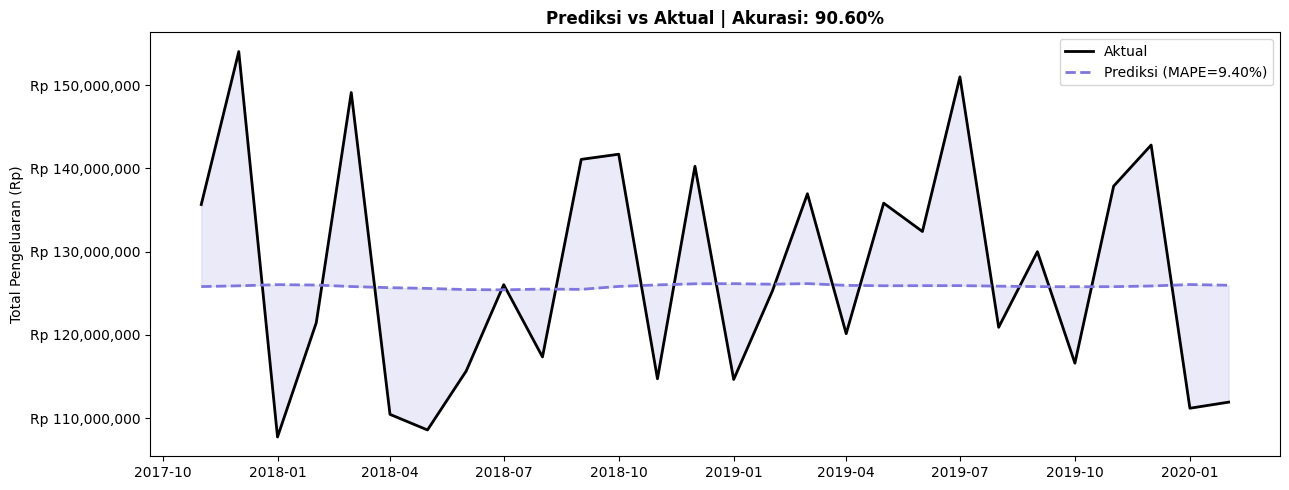

In [ ]:
def inverse_target(y_scaled, scaler, n_features, target_col=0):
    dummy = np.zeros((len(y_scaled), n_features))
    dummy[:, target_col] = y_scaled
    return scaler.inverse_transform(dummy)[:, target_col]

pred_scaled = model.predict(X_test, verbose=0).flatten()
pred_real   = inverse_target(pred_scaled, scaler, n_features)
true_real   = inverse_target(y_test, scaler, n_features)

mape = mean_absolute_percentage_error(true_real, pred_real) * 100
mae  = mean_absolute_error(true_real, pred_real)
rmse = np.sqrt(mean_squared_error(true_real, pred_real))
acc  = 100 - mape

print('=' * 50)
print('  HASIL EVALUASI')
print('=' * 50)
print(f'  MAPE    : {mape:.2f}%')
print(f'  MAE     : Rp {mae:,.2f}')
print(f'  RMSE    : Rp {rmse:,.2f}')
print(f'  Akurasi : {acc:.2f}%')
print('=' * 50)

# Plot prediksi vs aktual
test_dates = monthly['ds'].values[LOOKBACK + split:LOOKBACK + split + len(true_real)]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, true_real,  'k-',  linewidth=2, label='Aktual')
ax.plot(test_dates, pred_real,  '--',  color='#7F77DD', linewidth=2, label=f'Prediksi (MAPE={mape:.2f}%)')
ax.fill_between(test_dates, true_real, pred_real, alpha=0.15, color='#7F77DD')
ax.set_title(f'Prediksi vs Aktual | Akurasi: {acc:.2f}%', fontweight='bold')
ax.set_ylabel('Total Pengeluaran (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('evaluasi.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
print(df_raw.columns.tolist())

['Amount', 'Use Chip', 'Merchant City', 'Merchant State', 'MCC', 'Is Fraud?', 'Amount_Rupiah', 'date', 'Year', 'Month', 'Day']


📅 Prediksi 6 Bulan ke Depan:
----------------------------------------
  March 2020      : Rp 125,940,832.06
  April 2020      : Rp 125,583,413.77
  May 2020        : Rp 125,353,119.82
  June 2020       : Rp 125,223,830.22
  July 2020       : Rp 125,350,812.08
  August 2020     : Rp 125,522,719.52
----------------------------------------

✅ Prediksi bulan depan (via predict_next_month): Rp 125,940,832.06


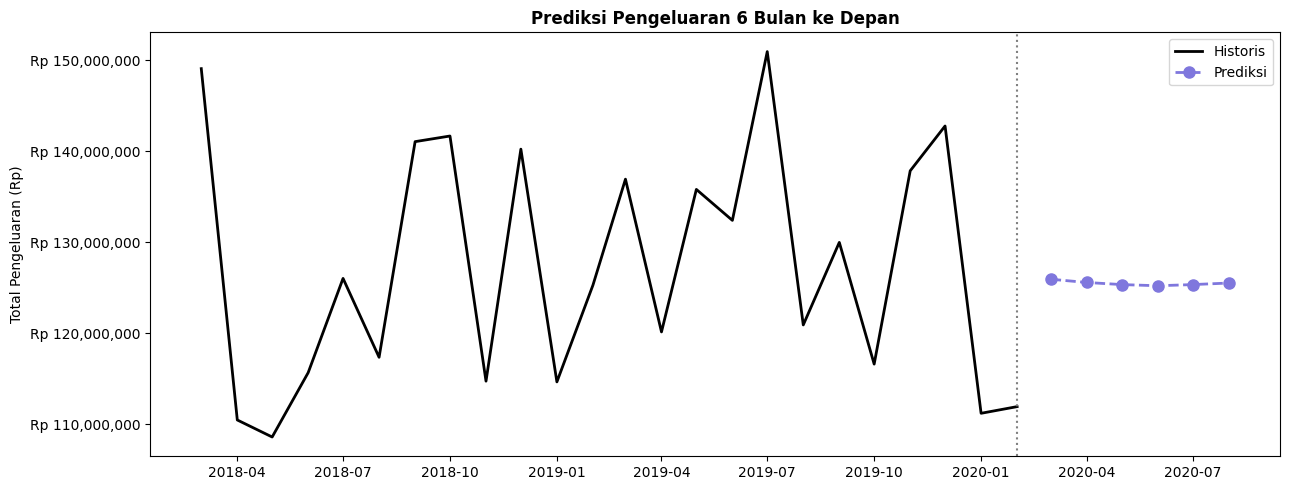

In [ ]:
def predict_future(model, last_sequence, scaler, n_months=6, n_features=8, target_col=0):
    """Prediksi pengeluaran N bulan ke depan."""
    predictions  = []
    current_seq  = last_sequence.copy()

    for _ in range(n_months):
        inp          = current_seq[np.newaxis, :, :]
        pred_scaled  = model.predict(inp, verbose=0)[0, 0]
        dummy        = np.zeros((1, n_features))
        dummy[0, target_col] = pred_scaled
        pred_real    = scaler.inverse_transform(dummy)[0, target_col]
        predictions.append(pred_real)
        new_row      = current_seq[-1].copy()
        new_row[target_col] = pred_scaled
        current_seq  = np.vstack([current_seq[1:], new_row])

    return predictions


# buat dipanggil backend
def predict_next_month(raw_data, model, scaler, feature_cols, lookback=12):
    monthly = raw_data.copy()

    # ✅ Fix konversi + nama kolom
    monthly['Amount_Rupiah'] = pd.to_numeric(monthly['Amount_Rupiah'], errors='coerce')
    monthly = monthly.dropna(subset=['Amount_Rupiah'])

    monthly = monthly.groupby(['Year', 'Month']).agg(
        total_amount=('Amount_Rupiah', 'sum'),
        jumlah_trx=('Amount_Rupiah', 'count'),
        rata_rata=('Amount_Rupiah', 'mean'),
        std_amount=('Amount_Rupiah', 'std')
    ).reset_index()

    monthly['ds'] = pd.to_datetime(dict(year=monthly['Year'], month=monthly['Month'], day=1))
    monthly = monthly.sort_values('ds').reset_index(drop=True)
    monthly['std_amount'] = monthly['std_amount'].fillna(0)
    monthly['month_sin'] = np.sin(2 * np.pi * monthly['Month'] / 12)
    monthly['month_cos'] = np.cos(2 * np.pi * monthly['Month'] / 12)
    monthly['lag_1']     = monthly['total_amount'].shift(1)
    monthly['lag_3']     = monthly['total_amount'].shift(3)
    monthly['rolling_3'] = monthly['total_amount'].shift(1).rolling(3).mean()
    monthly['rolling_6'] = monthly['total_amount'].shift(1).rolling(6).mean()
    monthly = monthly.dropna().reset_index(drop=True)

    data = monthly[feature_cols].values
    data_scaled = scaler.transform(data)
    last_seq = data_scaled[-lookback:]

    inp = last_seq[np.newaxis, :, :]
    pred_scaled = model.predict(inp, verbose=0)[0, 0]
    dummy = np.zeros((1, len(feature_cols)))
    dummy[0, 0] = pred_scaled
    pred_real = scaler.inverse_transform(dummy)[0, 0]

    return round(pred_real, 2)


# ini buat manggil visualisasi
N_MONTHS     = 6
last_seq     = data_scaled[-LOOKBACK:]
future_preds = predict_future(model, last_seq, scaler, N_MONTHS, n_features, TARGET_COL)
future_dates = pd.date_range(
    start=monthly['ds'].iloc[-1] + pd.DateOffset(months=1),
    periods=N_MONTHS, freq='MS'
)

print(f'📅 Prediksi {N_MONTHS} Bulan ke Depan:')
print('-' * 40)
for d, v in zip(future_dates, future_preds):
    print(f'  {d.strftime("%B %Y"):<15} : Rp {v:>9,.2f}')
print('-' * 40)

# Test predict_next_month buat simulasi paggilan untuk backednnya
hasil = predict_next_month(df_raw, model, scaler, feature_cols)
print(f'\n✅ Prediksi bulan depan (via predict_next_month): Rp {hasil:,.2f}')

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
hist = monthly.tail(24)
ax.plot(hist['ds'], hist['total_amount'], 'k-', linewidth=2, label='Historis')
ax.plot(future_dates, future_preds, 'o--', color='#7F77DD', linewidth=2, markersize=8, label='Prediksi')
ax.axvline(x=hist['ds'].iloc[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Prediksi Pengeluaran 6 Bulan ke Depan', fontweight='bold')
ax.set_ylabel('Total Pengeluaran (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
import pickle, os, zipfile, json

os.makedirs('saved_models', exist_ok=True)

# Format .keras
model.save('saved_models/smart_finance.keras')
print('✅ Tersimpan: smart_finance.keras')

# Format SavedModel
model.export('saved_models/smart_finance_savedmodel')
print('✅ Tersimpan: smart_finance_savedmodel/')

# Scaler & metadata
with open('saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

metadata = {
    'lookback'    : LOOKBACK,
    'n_features'  : n_features,
    'feature_cols': feature_cols,
    'mape'        : round(mape, 4),
    'accuracy'    : round(acc, 4)
}
with open('saved_models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Tersimpan: metadata.json')

# Verifikasi load ulang
loaded = keras.models.load_model(
    'saved_models/smart_finance.keras',
    custom_objects={
        'TemporalAttentionLayer': TemporalAttentionLayer,
        'SmartFinanceLoss': SmartFinanceLoss
    }
)
print('✅ Model berhasil di-load ulang')


print('\n' + '='*50)
print('  RINGKASAN AKHIR')
print('='*50)
print(f'  Functional API  : ✅')
print(f'  Custom Layer    : TemporalAttentionLayer ✅')
print(f'  Custom Loss     : SmartFinanceLoss ✅')
print(f'  Custom Callback : MAPELogger ✅')
print(f'  Format simpan   : .keras + SavedModel ✅')
print(f'  Inference       : predict_future() ✅')
print(f'  MAPE            : {mape:.2f}%')
print(f'  Akurasi         : {acc:.2f}% {"✅" if acc >= 90 else "⚠️"}')
print('='*50)

✅ Tersimpan: smart_finance.keras
Saved artifact at 'saved_models/smart_finance_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 8), dtype=tf.float32, name='input_sequence')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137511800006864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800003408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800008784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800008016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800007824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800006672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800008208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800011280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800008592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137511800011472: TensorSpec(shape=

In [ ]:
!pip install mlflow -q
print("✅ MLflow terinstall!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow

# Set tracking URI ke server MLflow kamu
mlflow.set_tracking_uri("https://thirsting-denote-suitably.ngrok-free.dev")
mlflow.set_experiment("SmartFinance")

print("✅ MLflow terhubung!")

MlflowException: API request to endpoint /api/2.0/mlflow/experiments/get-by-name failed with error code 404 != 200. Response body: '<!DOCTYPE html>
<html class="h-full" lang="en-US" dir="ltr">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Regular-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-RegularItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-Medium-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets.ngrok.com/fonts/euclid-square/EuclidSquare-MediumItalic-WebS.woff" as="font" type="font/woff" crossorigin="anonymous" />
    <link rel="preload" href="https://assets

In [ ]:
import mlflow
import mlflow.tensorflow

with mlflow.start_run(run_name="CNN_BiLSTM_Hybrid"):
    # Log parameter
    mlflow.log_param("lookback", LOOKBACK)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("epochs", 100)
    mlflow.log_param("arsitektur", "CNN_BiLSTM_Attention")
    mlflow.log_param("n_features", n_features)

    # Log metrik
    mlflow.log_metric("mape", mape)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("accuracy", acc)

    # Log model
    mlflow.tensorflow.log_model(model, "smart_finance_model")

    print(f"✅ Logged ke MLflow!")
    print(f"   MAPE    : {mape:.2f}%")
    print(f"   Akurasi : {acc:.2f}%")

2026/06/01 23:55:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 23:55:40 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/06/01 23:55:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp55m5773a/model, flavor: tensorflow). Fall back to return ['tensorflow==2.20.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


✅ Logged ke MLflow!
   MAPE    : 9.37%
   Akurasi : 90.63%
🏃 View run CNN_BiLSTM_Hybrid at: https://thirsting-denote-suitably.ngrok-free.dev/#/experiments/1/runs/fb67f7c90b854ff9a7e8218e543e4a64
🧪 View experiment at: https://thirsting-denote-suitably.ngrok-free.dev/#/experiments/1
